# Setting

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from api import split_expand
from langchain_openai import ChatOpenAI


llm4o = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o',
    temperature=1,
)

llm = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o-mini',
    temperature=1,
)

# 買進賣出需要的手續費
fee = {
    'tax_stock' : 0.003,          # 買進與賣出各0.003
    'tax_future' : 0.00002 * 2,   # 買進與賣出各0.00002
    'fee_stock' : 0.001425 * 2,   # 券商手續費公道價，買進與賣出各0.001425
    'fee_future' : 0.00002 * 2,   # 個家不大相同，以交易稅計算
    'sliding_price' : 0.00001,    # 滑價
}

data = [
    ["2330", "台積電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2454", "聯發科", "tw"],
    ["2382", "廣達", "tw"],
    ["3231", "緯創", "tw"],
    # ["2324","仁寶", "tw"],
    # ["4938", "和碩", "tw"],
    # ["2356","英業達", "tw"],
    # ["2881", "富邦金", "tw"],
    # ["2882", "國泰金", "tw"],
    # ["2412", "中華電", "tw"],
    # ["3045", "台灣大", "tw"],
    # ["6505", "台塑化", "tw"],
    # ["2603", "長榮", "tw"],
    
    ["AAPL", "Apple Inc.", "us"],
    ["GOOGL", "Google", "us"],
    ["MSFT", "Microsoft", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["TSLA", "Tesla", "us"],
    ["NVDA", "Nvidia", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
]

date_ranges = [
    ["20230401", "20240331"],
    ["20230701", "20240630"],
    ["20231001", "20240930"],
]



# Factor

2330 台積電 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,46,46,30,11,133,185,0.571429,0.500000,0.807018,0.002060,0.001054,"[[20230406, 0.0], [20230407, 0.007476635514018..."
test,16,20,7,2,45,56,0.511111,0.444444,0.888889,0.001002,0.000225,"[[20240102, 0.005084745762711864], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,49,56,39,30,174,185,0.505747,0.466667,0.620253,0.001730,0.001021,"[[20230406, 0.0], [20230407, 0.007476635514018..."
test,18,19,10,2,49,56,0.571429,0.486486,0.900000,0.001634,0.000606,"[[20240102, 0], [20240103, -0.0102739726027397..."


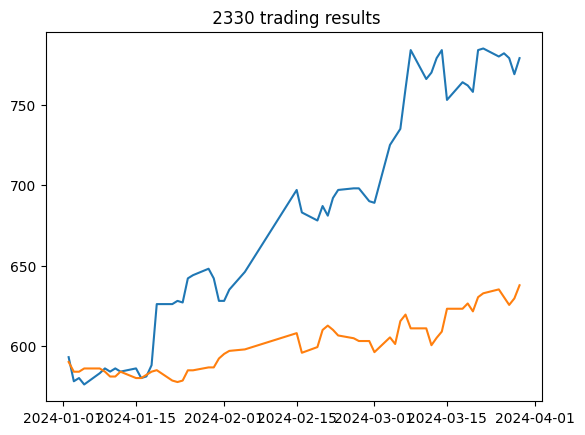

2317 鴻海 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,62,96,16,7,181,185,0.430939,0.392405,0.898551,0.000629,-0.000295,"[[20230406, -0.009569377990430622], [20230407,..."
test,24,29,1,2,56,56,0.446429,0.452830,0.923077,0.003249,0.003466,"[[20240102, 0.004784688995215311], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,8,16,68,89,181,185,0.41989,0.333333,0.082474,0.000969,-0.000600,"[[20230406, 0.009569377990430622], [20230407, ..."
test,9,5,18,22,54,56,0.50000,0.642857,0.290323,0.004967,0.014982,"[[20240102, -0.004784688995215311], [20240103,..."


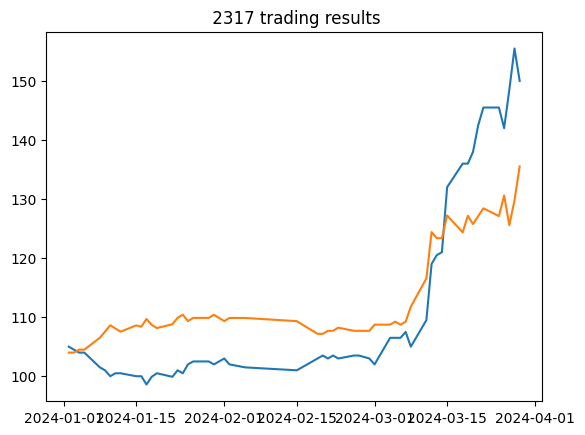

2454 聯發科 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,26,19,69,47,161,185,0.590062,0.577778,0.356164,0.002239,0.003224,"[[20230406, 0.027131782945736434], [20230407, ..."
test,9,14,13,7,43,56,0.511628,0.391304,0.562500,0.002271,-0.002241,"[[20240102, 0.028712871287128714], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,44,51,45,36,176,185,0.505682,0.463158,0.550000,0.001733,0.001428,"[[20230406, 0.027131782945736434], [20230407, ..."
test,16,20,12,6,54,56,0.518519,0.444444,0.727273,0.005074,0.003129,"[[20240102, 0.028712871287128714], [20240103, ..."


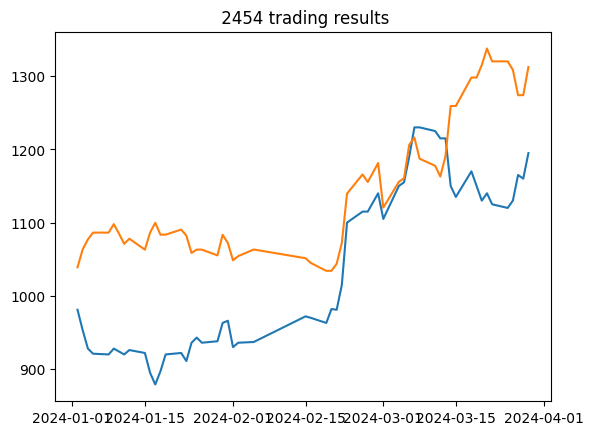

2382 廣達 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,68,55,25,21,169,185,0.550296,0.552846,0.764045,0.003221,0.003411,"[[20230406, 0], [20230407, 0.00559910414333706..."
test,22,18,9,5,54,56,0.574074,0.550000,0.814815,0.001648,0.001242,"[[20240102, 0], [20240103, -0.0214797136038186..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,81,71,17,13,182,185,0.538462,0.532895,0.861702,0.004315,0.003731,"[[20230406, 0.00897867564534244], [20230407, 0..."
test,26,24,5,1,56,56,0.553571,0.520000,0.962963,0.002810,0.000930,"[[20240102, -0.0467706013363029], [20240103, 0..."


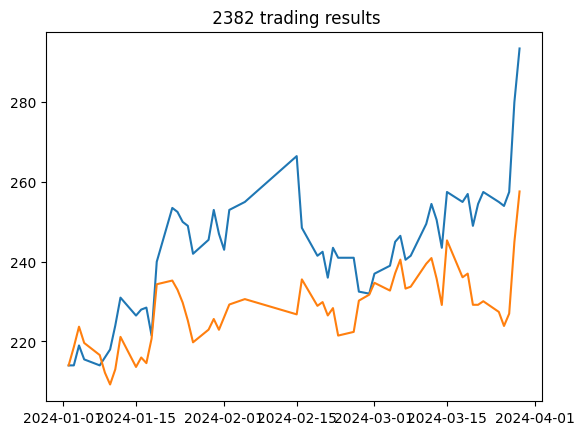

3231 緯創 tw


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,81,78,9,2,170,185,0.529412,0.509434,0.975904,0.004205,0.003515,"[[20230406, 0.0], [20230407, -0.02168674698795..."
test,21,30,1,2,54,56,0.407407,0.411765,0.913043,-0.003178,-0.003772,"[[20240102, -0.04969574036511148], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,63,62,31,18,174,185,0.540230,0.504000,0.777778,0.007941,0.006097,"[[20230406, 0.0], [20230407, -0.02168674698795..."
test,16,28,4,7,55,56,0.363636,0.363636,0.695652,-0.006030,-0.006414,"[[20240102, -0.04969574036511148], [20240103, ..."


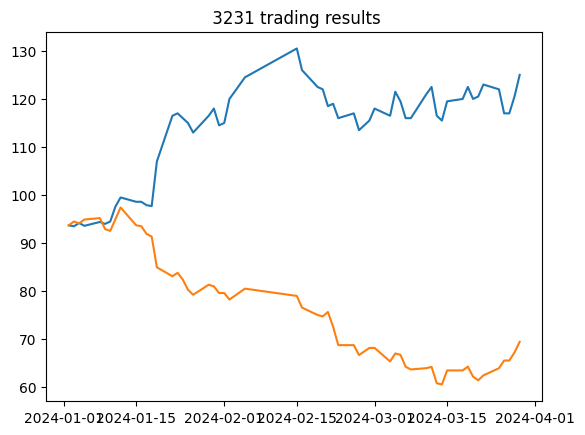

AAPL Apple Inc. us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,72,47,31,35,185,188,0.556757,0.605042,0.672897,0.001189,0.001683,"[[20230403, 0.011566323735313673], [20230404, ..."
test,12,16,16,15,59,61,0.474576,0.428571,0.444444,-0.000211,0.000210,"[[20240102, -0.008068394336094145], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,75,46,30,34,185,188,0.567568,0.619835,0.688073,0.001423,0.001934,"[[20230403, 0.011566323735313673], [20230404, ..."
test,13,17,16,15,61,61,0.475410,0.433333,0.464286,-0.000280,0.000042,"[[20240102, -0.008068394336094145], [20240103,..."


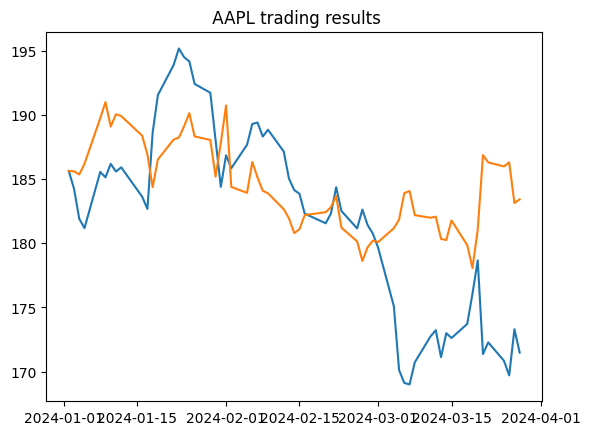

GOOGL Google us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,48,30,54,51,183,188,0.557377,0.615385,0.484848,0.001719,0.003503,"[[20230403, 0.019240160171891774], [20230404, ..."
test,8,5,20,28,61,61,0.459016,0.615385,0.222222,0.000576,0.003564,"[[20240102, 0.002742692168892269], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,29,54,51,184,188,0.565217,0.632911,0.49505,0.001907,0.003976,"[[20230403, 0.019240160171891774], [20230404, ..."
test,7,6,18,28,59,61,0.423729,0.538462,0.20000,-0.000196,0.001683,"[[20240102, 0.002742692168892269], [20240103, ..."


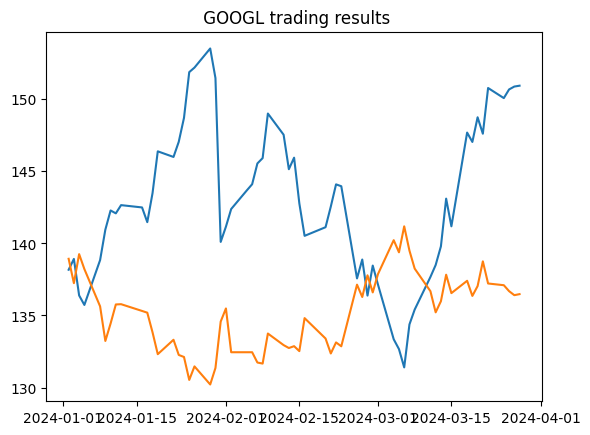

MSFT Microsoft us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,42,40,46,178,188,0.505618,0.543478,0.520833,-0.000668,-0.000221,"[[20230403, 0.002478012006142805], [20230404, ..."
test,21,24,6,8,59,61,0.457627,0.466667,0.724138,-0.001649,-0.000901,"[[20240102, -0.007997646177713607], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,56,46,32,43,177,188,0.497175,0.549020,0.565657,-0.000435,0.000299,"[[20230403, 0.002478012006142805], [20230404, ..."
test,21,24,5,9,59,61,0.440678,0.466667,0.700000,-0.001750,-0.000901,"[[20240102, -0.007997646177713607], [20240103,..."


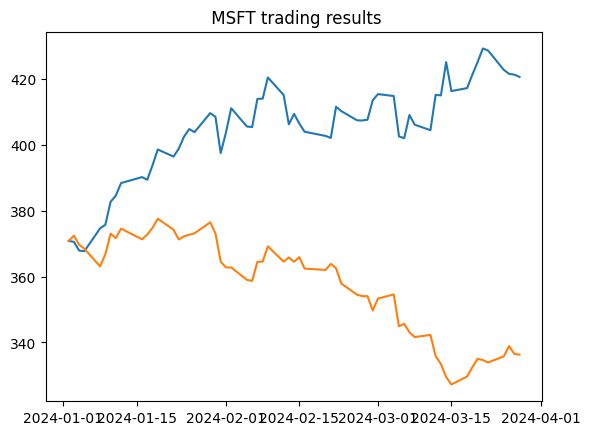

AMZN Amazon inc. us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,40,41,53,184,188,0.494565,0.555556,0.485437,-0.001023,0.000034,"[[20230403, -0.0010752688172042957], [20230404..."
test,20,15,9,16,60,61,0.483333,0.571429,0.555556,-0.000222,0.001480,"[[20240102, -0.010624257621749936], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,45,36,39,49,169,188,0.497041,0.555556,0.478723,-0.000435,0.000372,"[[20230403, -0.0010752688172042957], [20230404..."
test,19,11,9,16,55,61,0.509091,0.633333,0.542857,0.000285,0.002694,"[[20240102, 0], [20240103, -0.0048927613941018..."


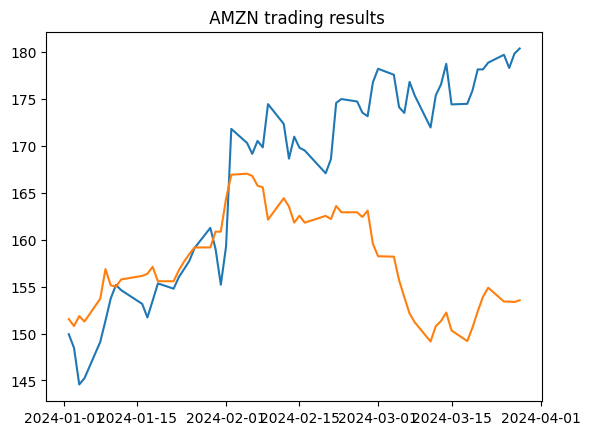

TSLA Tesla us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,42,30,54,59,185,188,0.518919,0.583333,0.415842,0.001147,0.002907,"[[20230403, -0.0257115702065929], [20230404, 0..."
test,5,6,26,22,59,61,0.525424,0.454545,0.185185,0.001588,0.001646,"[[20240102, 0.00663787587971859], [20240103, 0..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,40,31,53,57,181,188,0.513812,0.563380,0.412371,0.001311,0.002984,"[[20230403, -0.0257115702065929], [20230404, 0..."
test,3,6,27,23,59,61,0.508475,0.333333,0.115385,0.000587,-0.003631,"[[20240102, 0.00663787587971859], [20240103, 0..."


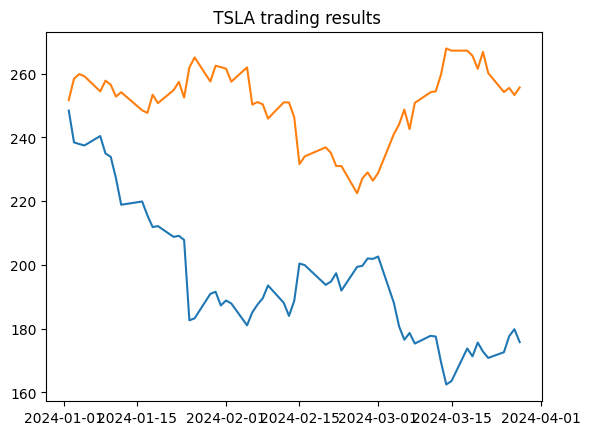

NVDA Nvidia us


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,65,55,34,24,178,188,0.556180,0.541667,0.730337,0.001477,0.001107,"[[20230403, -0.016576393180413665], [20230404,..."
test,25,19,5,10,59,61,0.508475,0.568182,0.714286,-0.001149,0.001512,"[[20240102, -0.02185037771099018], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,72,56,25,21,174,188,0.557471,0.562500,0.774194,0.002136,0.002075,"[[20230403, -0.016576393180413665], [20230404,..."
test,27,19,4,7,57,61,0.543860,0.586957,0.794118,0.000019,0.001995,"[[20240102, -0.02185037771099018], [20240103, ..."


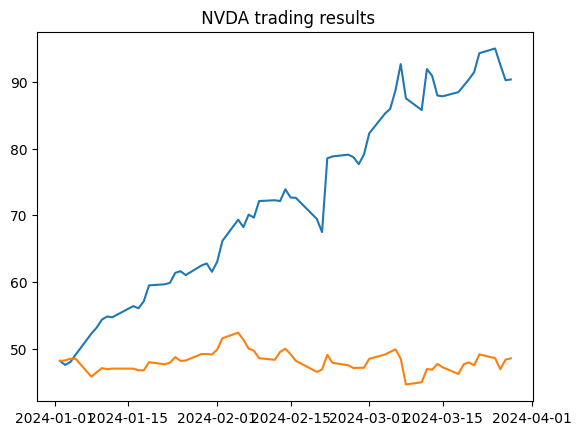

In [2]:
from factor import StockFactor

for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])

    stock_factor = StockFactor(env)
    
    stock_factor.generate_factors(llm4o)
    stock_factor.expand_factors(llm_factors=llm)
    train_datarange, test_datarange = stock_factor.split_exp()

    re_run = False # 是否重新訓練，True:刪除原有資料
    mode = 0
    df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)
    mode = 1
    df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)

    stock_factor.plot_acumulated_return()

## 顯示所有

In [10]:

import os
import json
import pandas as pd

for date_r in  date_ranges:
    env = {
        "start_date": date_r[0],
        "end_date": date_r[1],
    }

    path_out = f"out_stock/GA_factor_{env['start_date']}_{env['end_date']}/"
    skip_files = {"ac","factors_eng.json", "factors.json", "old_expand", ".DS_Store", "factors.json", "factors1.json", "embeddings.json", "expand.json", "expand1.json", "expand2.json", "clustered_summaries.json"}

    results = []
    index = []

    for folder in os.listdir(path_out):
        if folder in skip_files:
            continue
        folder_path = os.path.join(path_out, folder)
        for file in os.listdir(folder_path):
            if file in skip_files:
                continue
            path = os.path.join(folder_path, file, "result.json")
            with open(path, 'r') as f:
                json_data = json.load(f)
            results.append(json_data['test'])
            index.append(f"{folder}_{file}")

    df = pd.DataFrame(results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                        'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱

    # 計算平均值
    average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
    df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected = df.loc[:, selected_columns]
    df_sorted = df_selected.sort_index()

    display(df_sorted)
    display(average_row)

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,50.00%,64.29%,0.004967,0.014982,54,9,5,18,22
2330_ev,57.14%,48.65%,0.001634,0.000606,49,18,19,10,2
2382_ev,55.36%,52.00%,0.002810,0.000930,56,26,24,5,1
2454_ev,51.85%,44.44%,0.005074,0.003129,54,16,20,12,6
3231_ev,36.36%,36.36%,-0.006030,-0.006414,55,16,28,4,7
AAPL_ev,47.54%,43.33%,-0.000280,0.000042,61,13,17,16,15
AMZN_ev,50.91%,63.33%,0.000285,0.002694,55,19,11,9,16
GOOGL_ev,42.37%,53.85%,-0.000196,0.001683,59,7,6,18,28
MSFT_ev,44.07%,46.67%,-0.001750,-0.000901,59,21,24,5,9
NVDA_ev,54.39%,58.70%,0.000019,0.001995,57,27,19,4,7


accuracy        0.491672
precision       0.495410
ev              0.000647
precision_ev    0.001374
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,49.06%,47.50%,0.004652,6.374029e-03,53,19,21,7,6
2330_ev,66.67%,61.29%,0.005511,4.593589e-03,45,19,12,11,3
2382_ev,51.35%,52.17%,0.002906,1.437394e-03,37,12,11,7,7
2454_ev,46.67%,46.67%,0.002394,1.124980e-03,60,21,24,7,8
3231_ev,40.62%,10.00%,0.003164,-7.089364e-03,32,1,9,12,10
AAPL_ev,50.79%,46.51%,-0.001134,-7.281269e-04,63,20,23,12,8
AMZN_ev,49.21%,50.98%,-0.000796,-6.211074e-04,63,26,25,5,7
GOOGL_ev,32.26%,50.00%,-0.002914,-1.291917e-04,62,10,10,10,32
MSFT_ev,60.66%,63.64%,0.000179,8.996277e-07,61,28,16,9,8
NVDA_ev,44.44%,50.00%,-0.003048,-2.091116e-03,63,22,22,6,13


accuracy        0.491755
precision       0.457963
ev              0.000781
precision_ev   -0.000585
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,61.67%,57.58%,0.006452,0.004647,60,19,14,18,9
2330_ev,56.86%,51.22%,0.004780,0.003175,51,21,20,8,2
2382_ev,62.26%,63.16%,0.008064,0.007125,53,12,7,21,13
2454_ev,63.89%,70.00%,0.003783,0.006232,36,7,3,16,10
3231_ev,57.63%,0.00%,0.000444,0.000000,59,0,2,34,23
AAPL_ev,53.12%,60.00%,-0.000848,0.000621,64,24,16,10,14
AMZN_ev,40.98%,37.21%,-0.001604,-0.002711,61,16,27,9,9
GOOGL_ev,51.56%,50.00%,0.000010,-0.002918,64,12,12,21,19
MSFT_ev,50.79%,48.84%,0.000207,-0.001123,63,21,22,11,9
NVDA_ev,53.97%,52.78%,0.000167,-0.001097,63,19,17,15,12


accuracy        0.553630
precision       0.511818
ev              0.001920
precision_ev    0.001635
dtype: float64

2330 台積電 tw


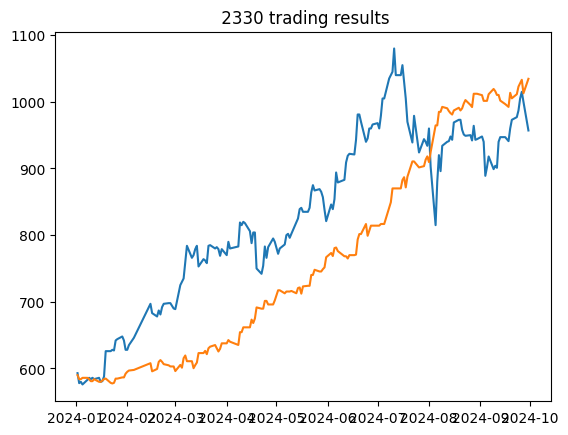

2317 鴻海 tw


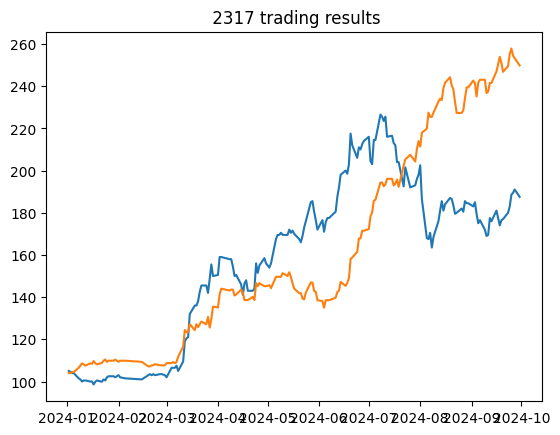

2454 聯發科 tw


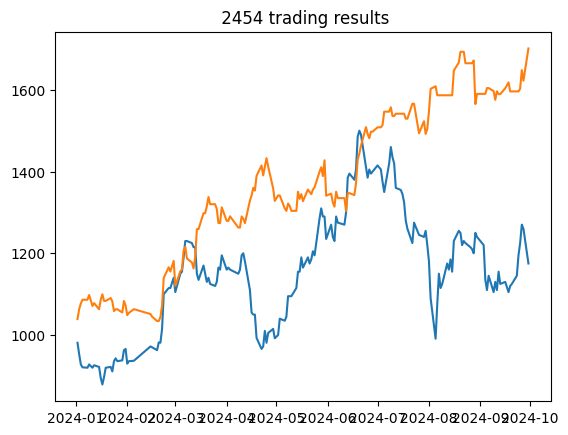

2382 廣達 tw


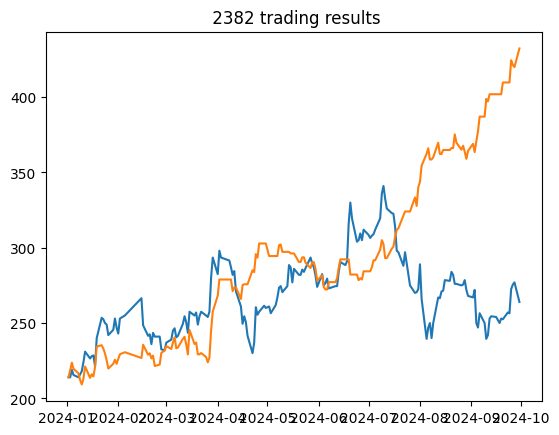

3231 緯創 tw


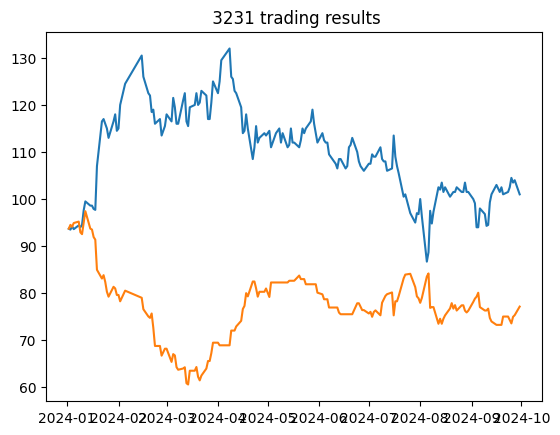

AAPL Apple Inc. us


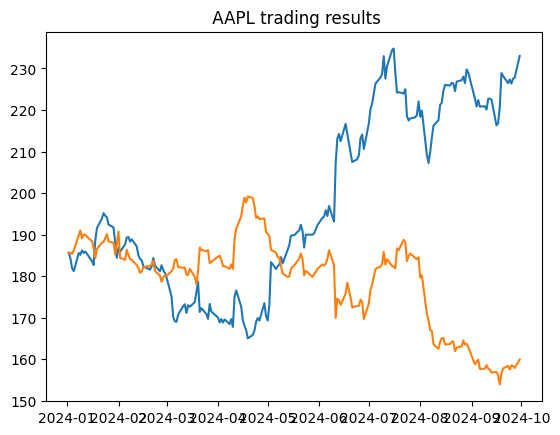

GOOGL Google us


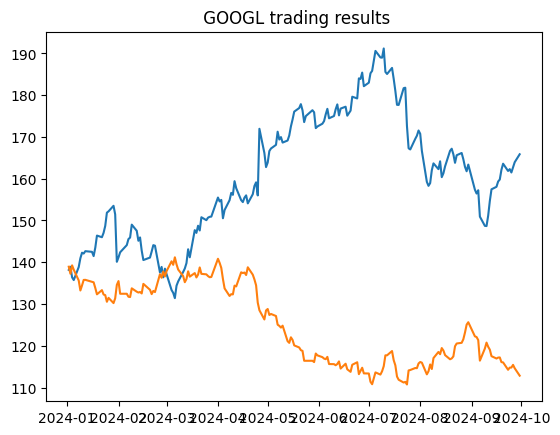

MSFT Microsoft us


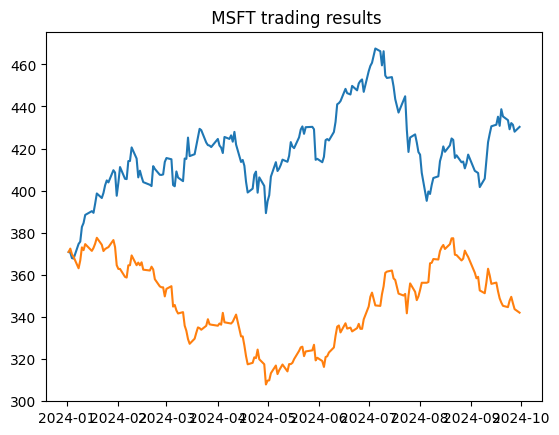

AMZN Amazon inc. us


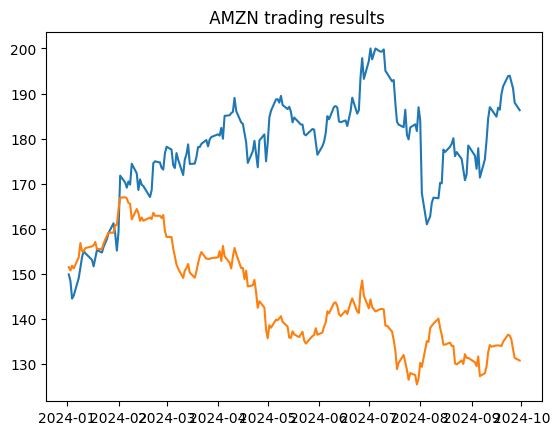

TSLA Tesla us


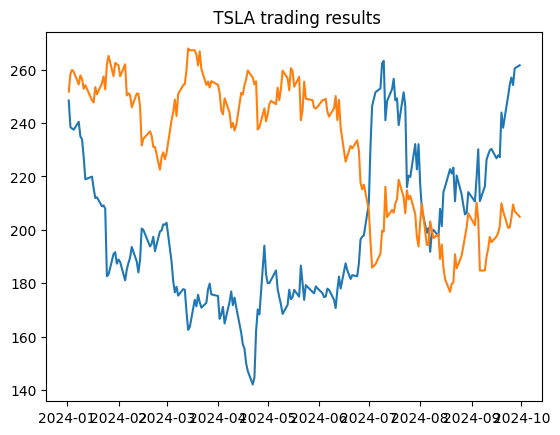

NVDA Nvidia us


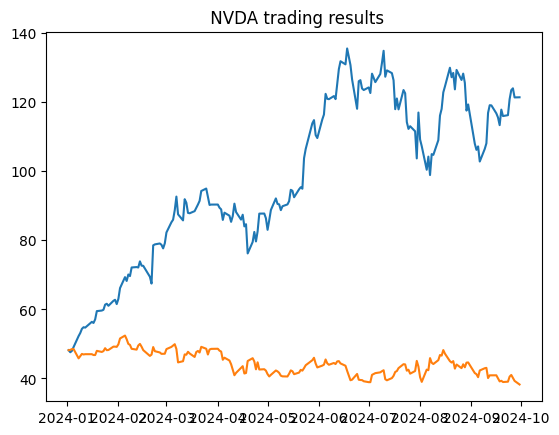

In [6]:
for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])
    stock_factor = StockFactor(env)
    stock_factor.plot_acumulated_return(date_ranges=date_ranges)

# Factor embedding

2330 台積電 tw
out_stock/Embd_20230401_20240331/2330//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,65,71,29,19,184,185,0.510870,0.477941,0.773810,0.001119,0.000509,"[[20230406, 0.0], [20230407, -0.00747663551401..."
test,22,22,9,2,55,56,0.563636,0.500000,0.916667,0.001856,0.000966,"[[20240102, 0.005084745762711864], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,62,67,29,21,179,185,0.508380,0.480620,0.746988,0.001368,0.000691,"[[20230406, 0.0], [20230407, 0.007476635514018..."
test,21,22,9,2,54,56,0.555556,0.488372,0.913043,0.001840,0.000877,"[[20240102, 0.005084745762711864], [20240103, ..."


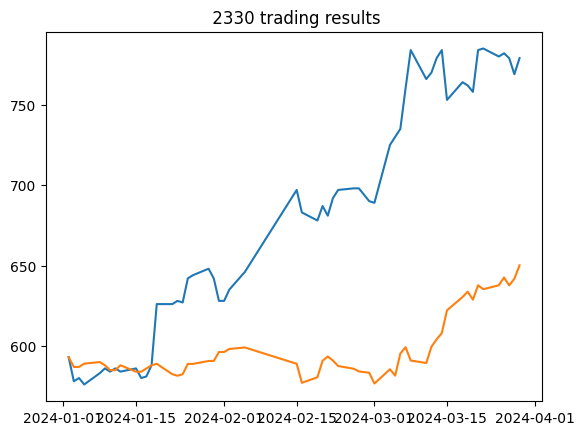

2317 鴻海 tw
out_stock/Embd_20230401_20240331/2317//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,55,87,22,19,183,185,0.420765,0.387324,0.743243,0.000377,-0.000494,"[[20230406, -0.009569377990430622], [20230407,..."
test,24,28,2,2,56,56,0.464286,0.461538,0.923077,0.003599,0.003722,"[[20240102, 0.004784688995215311], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,57,88,18,18,181,185,0.414365,0.393103,0.760000,0.000492,-0.000284,"[[20230406, -0.009569377990430622], [20230407,..."
test,24,27,2,2,55,56,0.472727,0.470588,0.923077,0.003844,0.003989,"[[20240102, 0.004784688995215311], [20240103, ..."


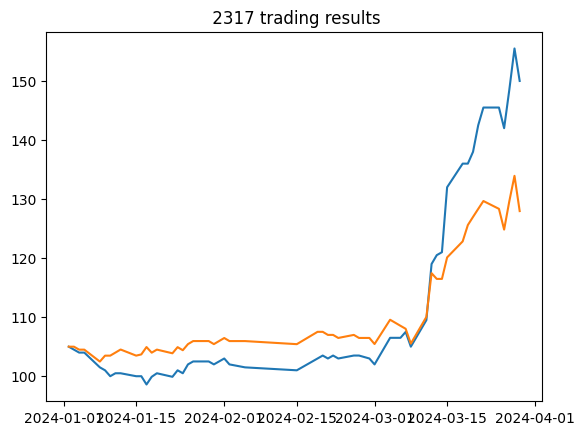

2454 聯發科 tw
out_stock/Embd_20230401_20240331/2454//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,18,14,62,47,141,185,0.567376,0.562500,0.276923,0.001814,0.002776,"[[20230406, -0.027131782945736434], [20230407,..."
test,7,11,14,14,46,56,0.456522,0.388889,0.333333,-0.001149,-0.003453,"[[20240102, 0.028712871287128714], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,14,10,86,71,181,185,0.552486,0.583333,0.164706,0.001738,0.006383,"[[20230406, 0], [20230407, -0.0], [20230410, 0..."
test,3,2,22,22,49,56,0.510204,0.600000,0.120000,0.003264,0.018223,"[[20240102, 0.028712871287128714], [20240103, ..."


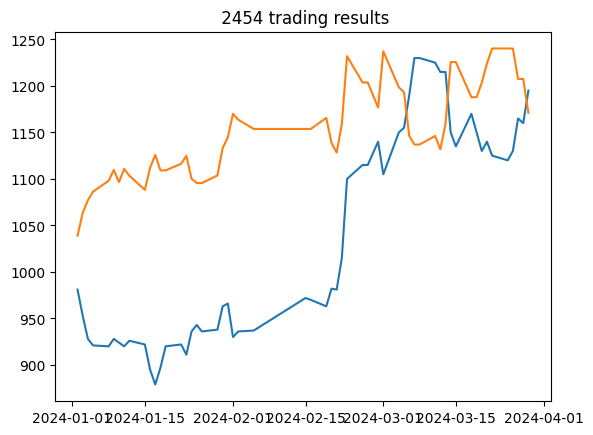

2382 廣達 tw
out_stock/Embd_20230401_20240331/2382//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,65,45,21,15,146,185,0.589041,0.590909,0.8125,0.005229,0.005713,"[[20230406, 0], [20230407, 0.00559910414333706..."
test,21,18,5,4,48,56,0.541667,0.538462,0.8400,0.001061,-0.000066,"[[20240102, -0.0467706013363029], [20240103, -..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,87,79,11,6,183,185,0.535519,0.524096,0.935484,0.003755,0.003153,"[[20230406, 0.00897867564534244], [20230407, 0..."
test,26,28,1,1,56,56,0.482143,0.481481,0.962963,-0.000266,-0.000734,"[[20240102, -0.0467706013363029], [20240103, 0..."


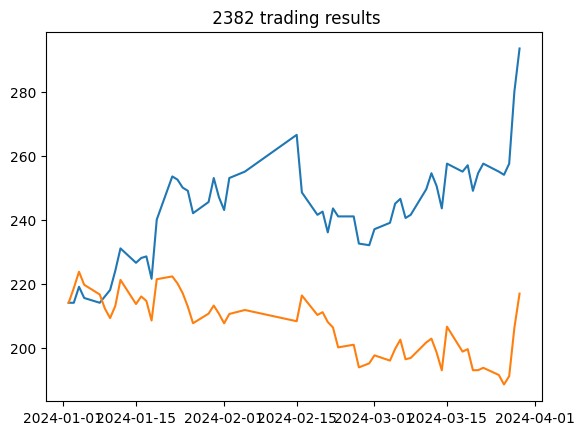

3231 緯創 tw
out_stock/Embd_20230401_20240331/3231//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,81,81,11,1,174,185,0.528736,0.500000,0.987805,0.004487,0.003227,"[[20230406, 0.0], [20230407, -0.02168674698795..."
test,22,31,1,1,55,56,0.418182,0.415094,0.956522,-0.003141,-0.003731,"[[20240102, -0.04969574036511148], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,86,87,10,1,184,185,0.521739,0.497110,0.988506,0.004301,0.003197,"[[20230406, 0.0], [20230407, -0.02168674698795..."
test,23,31,1,1,56,56,0.428571,0.425926,0.958333,-0.003028,-0.003603,"[[20240102, -0.04969574036511148], [20240103, ..."


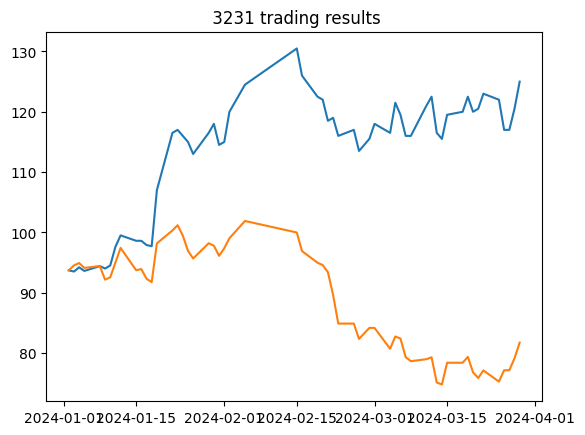

AAPL Apple Inc. us
out_stock/Embd_20230401_20240331/AAPL//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,81,48,30,28,187,188,0.593583,0.627907,0.743119,0.001735,0.002057,"[[20230403, 0.011566323735313673], [20230404, ..."
test,15,17,16,13,61,61,0.508197,0.468750,0.535714,0.000065,0.000368,"[[20240102, -0.008068394336094145], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,77,47,30,31,185,188,0.578378,0.620968,0.712963,0.001591,0.002032,"[[20230403, 0.011566323735313673], [20230404, ..."
test,14,16,17,13,60,61,0.516667,0.466667,0.518519,0.000030,0.000191,"[[20240102, -0.008068394336094145], [20240103,..."


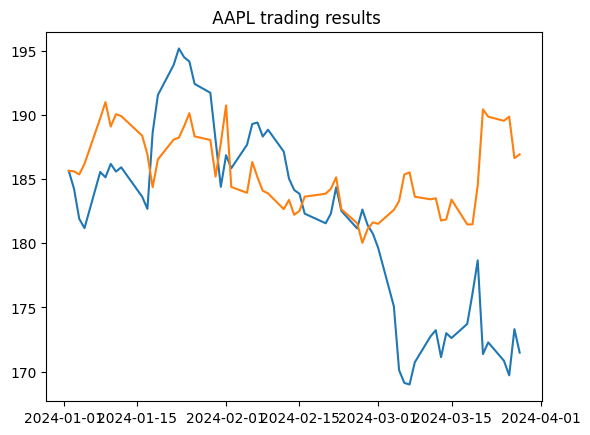

GOOGL Google us
out_stock/Embd_20230401_20240331/GOOGL//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,49,30,54,51,184,188,0.559783,0.620253,0.490000,0.002063,0.004218,"[[20230403, 0.019240160171891774], [20230404, ..."
test,7,7,18,27,59,61,0.423729,0.500000,0.205882,-0.000496,0.000390,"[[20240102, 0.002742692168892269], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,55,36,49,47,187,188,0.556150,0.604396,0.539216,0.002050,0.003713,"[[20230403, 0.019240160171891774], [20230404, ..."
test,9,6,19,26,60,61,0.466667,0.600000,0.257143,0.000616,0.002773,"[[20240102, 0.002742692168892269], [20240103, ..."


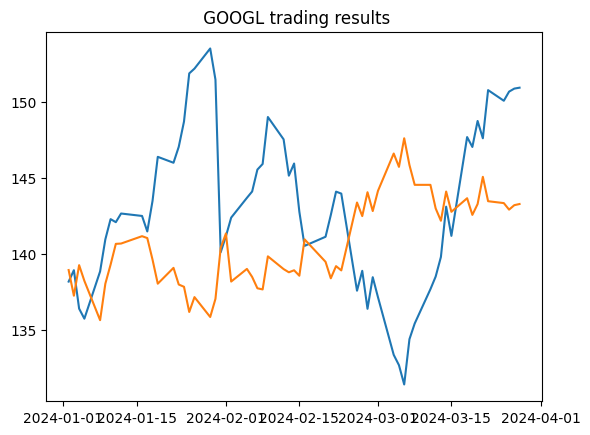

MSFT Microsoft us
out_stock/Embd_20230401_20240331/MSFT//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,43,29,9,16,97,188,0.536082,0.597222,0.728814,0.000425,0.001343,"[[20230403, 0.002478012006142805], [20230404, ..."
test,12,19,2,4,37,61,0.378378,0.387097,0.750000,-0.002092,-0.001355,"[[20240102, 0], [20240103, 0], [20240104, -0.0..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,4,3,82,94,183,188,0.469945,0.571429,0.040816,-0.000721,-0.001817,"[[20230403, -0.002478012006142805], [20230404,..."
test,0,2,28,30,60,61,0.466667,0.000000,0.000000,-0.001208,0.000000,"[[20240102, 0.007997646177713607], [20240103, ..."


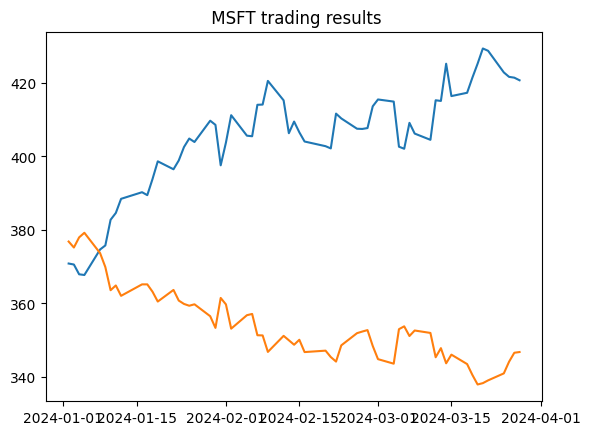

AMZN Amazon inc. us
out_stock/Embd_20230401_20240331/AMZN//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,89,71,13,13,186,188,0.548387,0.556250,0.872549,0.001045,0.001100,"[[20230403, 0.0010752688172042957], [20230404,..."
test,29,19,5,7,60,61,0.566667,0.604167,0.805556,0.001800,0.002343,"[[20240102, -0.010624257621749936], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,89,71,13,13,186,188,0.548387,0.556250,0.872549,0.001045,0.001100,"[[20230403, 0.0010752688172042957], [20230404,..."
test,30,19,5,6,60,61,0.583333,0.612245,0.833333,0.002127,0.002495,"[[20240102, -0.010624257621749936], [20240103,..."


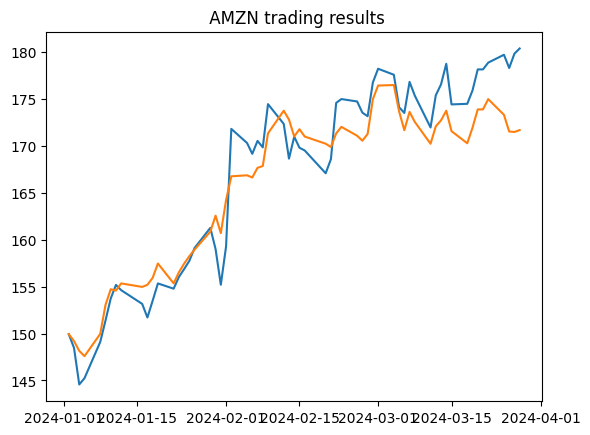

TSLA Tesla us
out_stock/Embd_20230401_20240331/TSLA//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,42,28,50,53,173,188,0.531792,0.600000,0.442105,0.002119,0.004113,"[[20230403, -0.0257115702065929], [20230404, 0..."
test,5,7,25,21,58,61,0.517241,0.416667,0.192308,0.000895,-0.001192,"[[20240102, 0.00663787587971859], [20240103, 0..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,37,26,53,59,175,188,0.514286,0.587302,0.385417,0.001928,0.003967,"[[20230403, -0.0257115702065929], [20230404, 0..."
test,5,7,26,21,59,61,0.525424,0.416667,0.192308,0.000963,-0.001192,"[[20240102, 0.00663787587971859], [20240103, 0..."


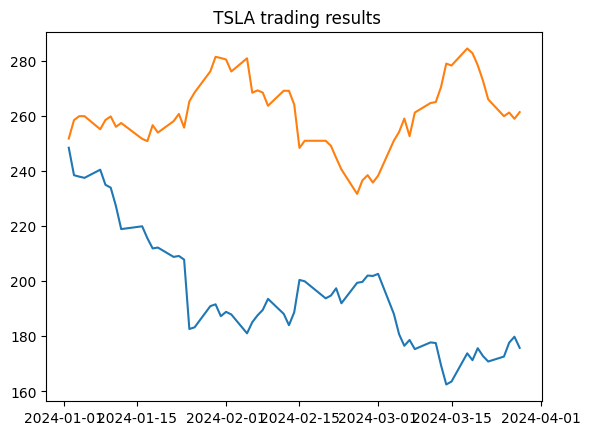

NVDA Nvidia us
out_stock/Embd_20230401_20240331/NVDA//expand.json


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,46,40,37,34,157,188,0.528662,0.534884,0.575000,0.000559,0.000243,"[[20230403, -0.016576393180413665], [20230404,..."
test,21,20,5,12,58,61,0.448276,0.512195,0.636364,-0.002721,0.000401,"[[20240102, -0.02185037771099018], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,66,58,25,22,171,188,0.532164,0.532258,0.750000,0.001702,0.001614,"[[20230403, -0.016576393180413665], [20230404,..."
test,26,21,4,7,58,61,0.517241,0.553191,0.787879,-0.001179,0.001215,"[[20240102, -0.02185037771099018], [20240103, ..."


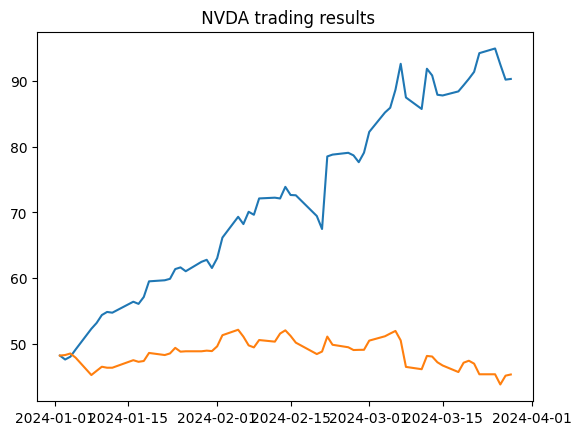

In [2]:
from factor_embd import FactorEmb

for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }

    print(env['stock_id'], env['stock_name'], env['country'])


    factor_embd = FactorEmb(env)
    factor_embd.generate_factors(llm4o)
    factor_embd.expand_factors(llm_factors=llm)
    train_datarange, test_datarange = factor_embd.split_exp()

    re_run = True # 是否重新訓練，True:刪除原有資料
    mode = 0
    df = factor_embd.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)
    mode = 1
    df = factor_embd.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)

    factor_embd.plot_acumulated_return()


## 顯示所有

In [9]:
import os
import json
import pandas as pd

env = {
    "start_date": "20230401",
    "end_date": "20240331",
    
    # "start_date" : "20230701",
    # "end_date" : "20240630",
    
    # "start_date" : "20231001",
    # "end_date" : "20240930",
}

path_out = f"out_stock/Embd_{env['start_date']}_{env['end_date']}/"
skip_files = {"ac","factors_eng.json", "factors.json", "old_expand", ".DS_Store", "factors.json", "factors1.json", "embeddings.json", "expand.json", "expand1.json", "expand2.json", "clustered_summaries.json"}

results = []
index = []

for folder in os.listdir(path_out):
    if folder in skip_files:
        continue
    folder_path = os.path.join(path_out, folder)
    for file in os.listdir(folder_path):
        if file in skip_files:
            continue
        path = os.path.join(folder_path, file, "result.json")
        with open(path, 'r') as f:
            json_data = json.load(f)

        results.append(json_data['test'])
        index.append(f"{folder}_{file}")

df = pd.DataFrame(results, index=index)
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                    'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱

# 計算平均值
average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
df_selected = df.loc[:, selected_columns]
df_sorted = df_selected.sort_index()

display(df_sorted)
display(average_row)

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,47.27%,47.06%,0.003844,0.003989,55,24,27,2,2
2330_ev,55.56%,48.84%,0.001840,0.000877,54,21,22,9,2
2382_ev,48.21%,48.15%,-0.000266,-0.000734,56,26,28,1,1
2454_ev,51.02%,60.00%,0.003264,0.018223,49,3,2,22,22
3231_ev,42.86%,42.59%,-0.003028,-0.003603,56,23,31,1,1
AAPL_ev,51.67%,46.67%,0.000030,0.000191,60,14,16,17,13
AMZN_ev,58.33%,61.22%,0.002127,0.002495,60,30,19,5,6
GOOGL_ev,46.67%,60.00%,0.000616,0.002773,60,9,6,19,26
MSFT_ev,46.67%,0.00%,-0.001208,0.000000,60,0,2,28,30
NVDA_ev,51.72%,55.32%,-0.001179,0.001215,58,26,21,4,7


accuracy        0.502291
precision       0.465012
ev              0.000637
precision_ev    0.002203
dtype: float64

FileNotFoundError: [Errno 2] No such file or directory: 'out_stock/Embd_20230701_20240630/'

In [ ]:
factor_embd.plot_acumulated_return(date_ranges=date_ranges)

# Factor 2

2330 台積電 tw
factor_expanding2


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,70,76,24,15,185,185,0.508108,0.479452,0.823529,0.001063,0.000442,"[[20230406, -0.0], [20230407, 0.00747663551401..."
test,20,28,4,4,56,56,0.428571,0.416667,0.833333,0.000671,0.000173,"[[20240102, 0.005084745762711864], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,50,55,20,20,145,185,0.482759,0.476190,0.714286,0.001310,0.000720,"[[20230406, -0.0], [20230407, 0.00747663551401..."
test,14,20,5,3,42,56,0.452381,0.411765,0.823529,0.000199,-0.000234,"[[20240102, 0.005084745762711864], [20240103, ..."


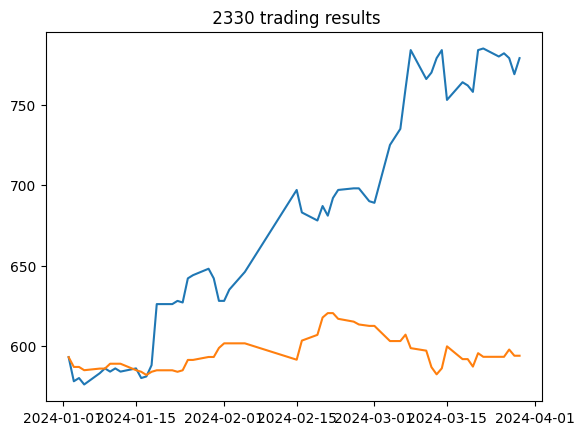

2317 鴻海 tw
factor_expanding2


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,44,55,38,25,162,185,0.506173,0.444444,0.637681,0.001024,0.000108,"[[20230406, -0.009569377990430622], [20230407,..."
test,8,13,11,21,53,56,0.358491,0.380952,0.275862,-0.004081,-0.000619,"[[20240102, -0.004784688995215311], [20240103,..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,44,57,46,38,185,185,0.486486,0.435644,0.536585,0.001338,0.000284,"[[20230406, -0.009569377990430622], [20230407,..."
test,8,13,13,22,56,56,0.375000,0.380952,0.266667,-0.003777,-0.000619,"[[20240102, -0.004784688995215311], [20240103,..."


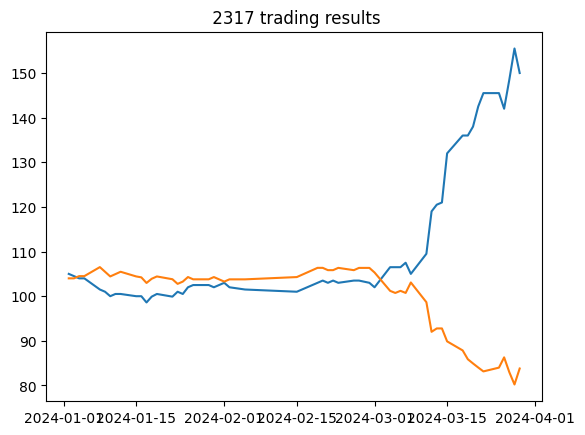

2454 聯發科 tw
factor_expanding2


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,34,32,31,19,116,185,0.560345,0.515152,0.641509,0.001269,0.001075,"[[20230406, 0.027131782945736434], [20230407, ..."
test,10,20,2,1,33,56,0.363636,0.333333,0.909091,-0.002711,-0.001523,"[[20240102, 0], [20240103, -0.0235655737704918..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,62,73,30,20,185,185,0.497297,0.459259,0.756098,0.001023,0.000558,"[[20230406, 0.027131782945736434], [20230407, ..."
test,21,29,6,0,56,56,0.482143,0.420000,1.000000,0.002888,0.001252,"[[20240102, 0.028712871287128714], [20240103, ..."


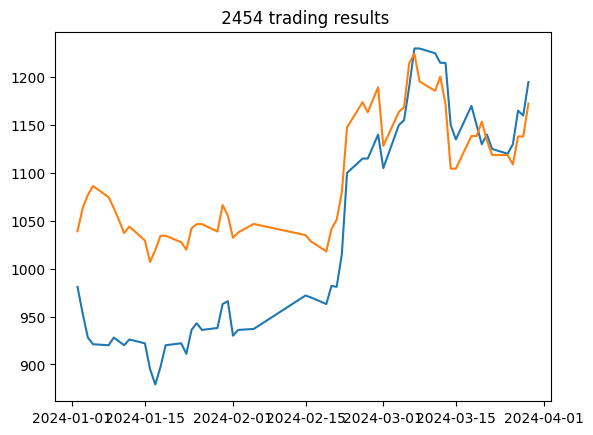

2382 廣達 tw
factor_expanding2


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,86,77,13,9,185,185,0.535135,0.527607,0.905263,0.003066,0.002548,"[[20230406, -0.00897867564534244], [20230407, ..."
test,27,28,1,0,56,56,0.500000,0.490909,1.000000,0.000232,-0.000467,"[[20240102, -0.0467706013363029], [20240103, 0..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,84,74,15,12,185,185,0.535135,0.531646,0.875,0.003887,0.003110,"[[20230406, -0.00897867564534244], [20230407, ..."
test,27,28,1,0,56,56,0.500000,0.490909,1.000,0.000232,-0.000467,"[[20240102, -0.0467706013363029], [20240103, 0..."


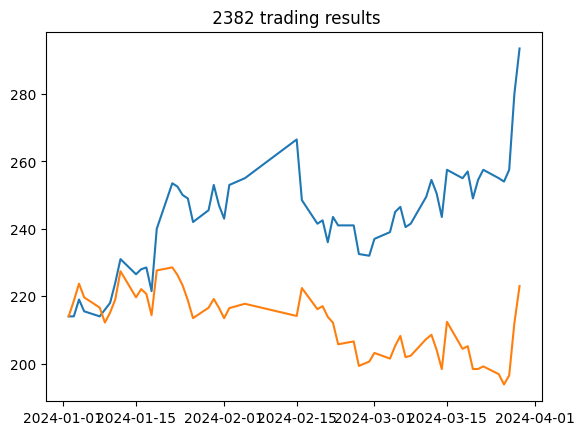

3231 緯創 tw
factor_expanding2


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,64,62,33,26,185,185,0.524324,0.507937,0.711111,0.003705,0.003880,"[[20230406, 0.0], [20230407, 0.021686746987951..."
test,19,26,5,6,56,56,0.428571,0.422222,0.760000,-0.003887,-0.004858,"[[20240102, -0.04969574036511148], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,69,67,29,20,185,185,0.529730,0.507353,0.775281,0.004382,0.004055,"[[20230406, 0.0], [20230407, 0.021686746987951..."
test,20,27,4,5,56,56,0.428571,0.425532,0.800000,-0.004307,-0.004901,"[[20240102, -0.04969574036511148], [20240103, ..."


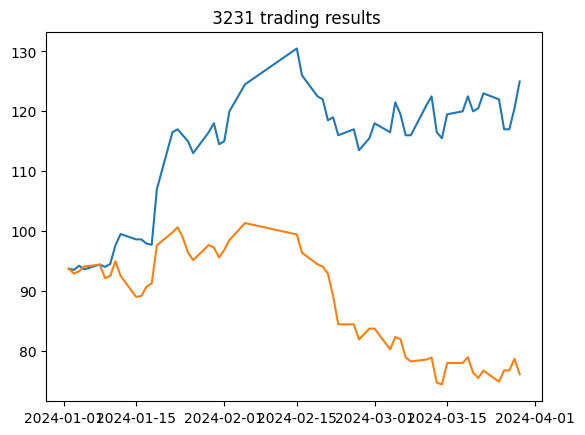

AAPL Apple Inc. us
factor_expanding2


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,36,19,18,22,95,188,0.568421,0.654545,0.620690,0.001680,0.002707,"[[20230403, -0.011566323735313673], [20230404,..."
test,17,15,1,1,34,61,0.529412,0.531250,0.944444,0.002727,0.002735,"[[20240102, 0], [20240103, 0], [20240104, -0.0..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,24,12,66,86,188,188,0.478723,0.666667,0.218182,-0.000149,0.002483,"[[20230403, -0.011566323735313673], [20230404,..."
test,11,11,22,17,61,61,0.540984,0.500000,0.392857,0.000292,0.000850,"[[20240102, 0.008068394336094145], [20240103, ..."


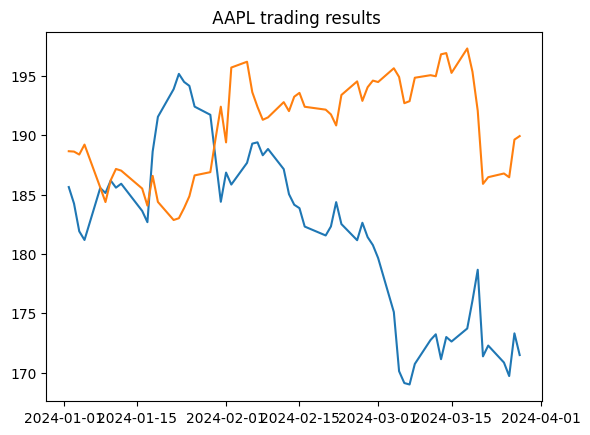

GOOGL Google us
factor_expanding2


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,9,0,82,97,188,188,0.484043,1.00,0.084906,-0.000696,0.00000,"[[20230403, -0.019240160171891774], [20230404,..."
test,3,1,24,33,61,61,0.442623,0.75,0.083333,-0.000422,0.00397,"[[20240102, 0.002742692168892269], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,11,2,80,95,188,188,0.484043,0.846154,0.103774,-0.000174,0.010203,"[[20230403, -0.019240160171891774], [20230404,..."
test,4,3,22,32,61,61,0.426230,0.571429,0.111111,-0.000183,0.003312,"[[20240102, 0.002742692168892269], [20240103, ..."


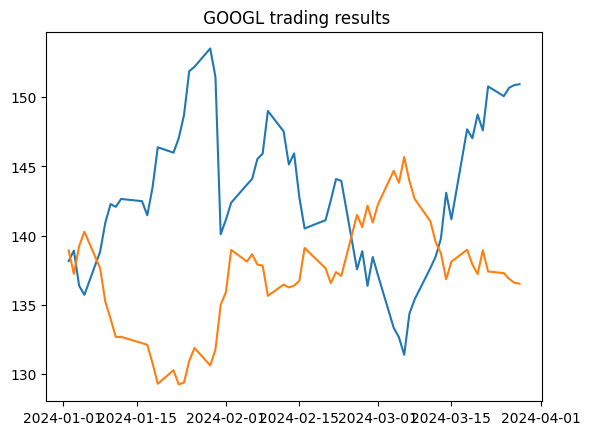

MSFT Microsoft us
factor_expanding2


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,21,8,43,31,103,188,0.621359,0.724138,0.403846,0.003264,0.004612,"[[20230403, -0.002478012006142805], [20230404,..."
test,4,2,11,19,36,61,0.416667,0.666667,0.173913,-0.001406,0.005166,"[[20240102, 0.007997646177713607], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,28,12,75,73,188,188,0.547872,0.700000,0.277228,0.001031,0.003792,"[[20230403, -0.002478012006142805], [20230404,..."
test,10,9,21,21,61,61,0.508197,0.526316,0.322581,0.000548,0.001917,"[[20240102, 0.007997646177713607], [20240103, ..."


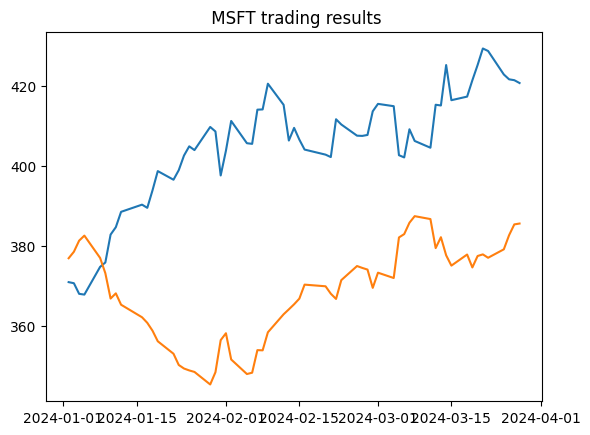

AMZN Amazon inc. us
factor_expanding2


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,30,13,72,73,188,188,0.542553,0.697674,0.291262,0.000945,0.003862,"[[20230403, -0.0010752688172042957], [20230404..."
test,20,11,14,16,61,61,0.557377,0.645161,0.555556,0.002006,0.003694,"[[20240102, 0.010624257621749936], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,38,24,61,65,188,188,0.526596,0.612903,0.368932,0.002050,0.004353,"[[20230403, -0.0010752688172042957], [20230404..."
test,23,17,8,13,61,61,0.508197,0.575000,0.638889,0.001289,0.002316,"[[20240102, -0.010624257621749936], [20240103,..."


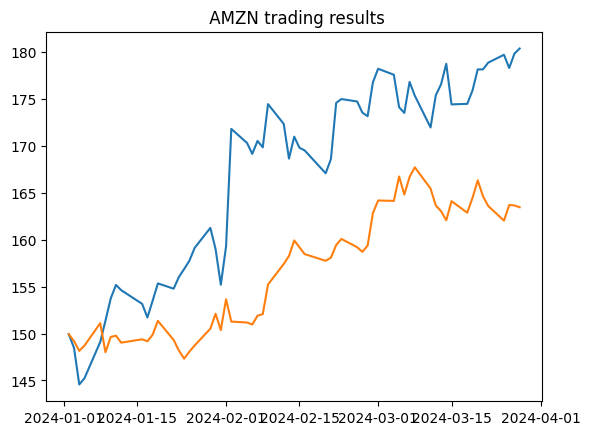

TSLA Tesla us
factor_expanding2
Processing for date 20240328
Processing for date 20240327
Processing for date 20240326
Processing for date 20240325
Processing for date 20240322
Processing for date 20240321
Processing for date 20240320
Processing for date 20240319
Processing for date 20240318
Processing for date 20240315
Processing for date 20240314
Processing for date 20240313
Processing for date 20240312
Processing for date 20240311
Processing for date 20240308
Processing for date 20240307
Processing for date 20240306
Processing for date 20240305
Processing for date 20240304
Processing for date 20240301
Processing for date 20240229
Processing for date 20240228
Processing for date 20240227
Processing for date 20240226
Processing for date 20240223
Processing for date 20240222
Processing for date 20240221
Processing for date 20240220
Processing for date 20240216
Processing for date 20240215
Processing for date 20240214
Processing for date 20240213
Processing for date 20240212
Processing 

,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,13,3,82,90,188,188,0.505319,0.8125,0.126214,0.000357,0.008243,"[[20230403, 0.0257115702065929], [20230404, 0...."
test,4,4,30,23,61,61,0.557377,0.5000,0.148148,0.003405,0.007056,"[[20240102, 0.00663787587971859], [20240103, 0..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,20,10,75,83,188,188,0.505319,0.666667,0.194175,0.001495,0.007964,"[[20230403, 0.0257115702065929], [20230404, 0...."
test,8,10,24,19,61,61,0.524590,0.444444,0.296296,0.001253,-0.000511,"[[20240102, 0.00663787587971859], [20240103, 0..."


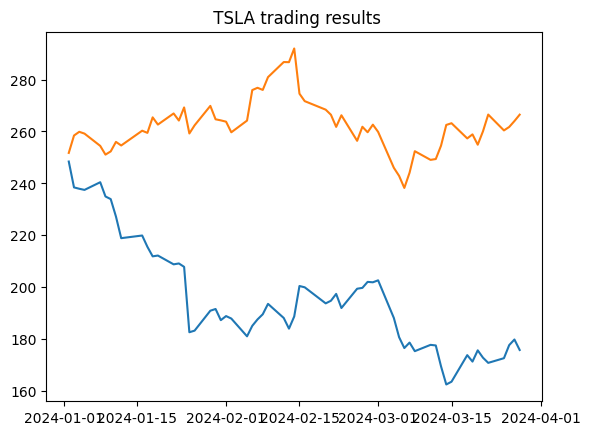

NVDA Nvidia us
Generating factors for NVDA
factor_expanding2
Processing for date 20240328
Processing for date 20240327
Processing for date 20240326
Processing for date 20240325
Processing for date 20240322
Processing for date 20240321
Processing for date 20240320
Processing for date 20240319
Processing for date 20240318
Processing for date 20240315
Processing for date 20240314
Processing for date 20240313
Processing for date 20240312
Processing for date 20240311
Processing for date 20240308
Processing for date 20240307
Processing for date 20240306
Processing for date 20240305
Processing for date 20240304
Processing for date 20240301
Processing for date 20240229
Processing for date 20240228
Processing for date 20240227
Processing for date 20240226
Processing for date 20240223
Processing for date 20240222
Processing for date 20240221
Processing for date 20240220
Processing for date 20240216
Processing for date 20240215
Processing for date 20240214
Processing for date 20240213
Processing 

,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,44,33,58,53,188,188,0.542553,0.571429,0.453608,0.001748,0.002977,"[[20230403, -0.016576393180413665], [20230404,..."
test,25,22,3,11,61,61,0.459016,0.531915,0.694444,-0.001580,0.001269,"[[20240102, -0.02185037771099018], [20240103, ..."


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,38,29,62,59,188,188,0.531915,0.567164,0.391753,0.001718,0.003380,"[[20230403, -0.016576393180413665], [20230404,..."
test,22,17,8,14,61,61,0.491803,0.564103,0.611111,-0.001672,0.001457,"[[20240102, -0.02185037771099018], [20240103, ..."


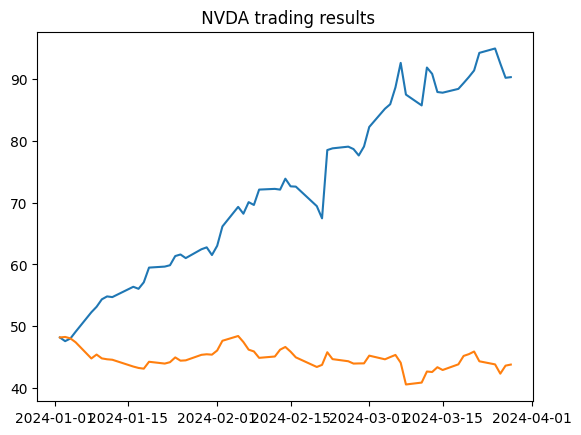

In [2]:
from factor2 import Factor2

# for date_r in date_ranges:
for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date": "20230401",
        "end_date": "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])

    stock_factor = Factor2(env)
    
    stock_factor.generate_factors(llm4o)
    stock_factor.expand_factors(llm_factors=llm)
    train_datarange, test_datarange = stock_factor.split_exp()

    re_run = False # 是否重新訓練，True:刪除原有資料
    mode = 0
    df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)
    mode = 1
    df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
    display(df)

    stock_factor.plot_acumulated_return()

## 顯示所有

In [3]:

import os
import json
import pandas as pd

env = {
    "start_date": "20230401",
    "end_date": "20240331",
    
    # "start_date" : "20230701",
    # "end_date" : "20240630",
    
    # "start_date" : "20231001",
    # "end_date" : "20240930",
}

path_out = f"out_stock/Factor2_{env['start_date']}_{env['end_date']}/"
skip_files = {"ac","factors_eng.json", "factors.json", "old_expand", ".DS_Store", "factors.json", "factors1.json", "embeddings.json", "expand.json", "expand1.json", "expand2.json", "clustered_summaries.json"}

results = []
index = []

for folder in os.listdir(path_out):
    if folder in skip_files:
        continue
    folder_path = os.path.join(path_out, folder)
    for file in os.listdir(folder_path):
        if file in skip_files:
            continue
        path = os.path.join(folder_path, file, "result.json")
        with open(path, 'r') as f:
            json_data = json.load(f)
        results.append(json_data['test'])
        index.append(f"{folder}_{file}")

df = pd.DataFrame(results, index=index)
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                    'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱

# 計算平均值
average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
df_selected = df.loc[:, selected_columns]
df_sorted = df_selected.sort_index()

display(df_sorted)
display(average_row)

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,37.50%,38.10%,-0.003777,-0.000619,56,8,13,13,22
2330_ev,45.24%,41.18%,0.000199,-0.000234,42,14,20,5,3
2382_ev,50.00%,49.09%,0.000232,-0.000467,56,27,28,1,0
2454_ev,48.21%,42.00%,0.002888,0.001252,56,21,29,6,0
3231_ev,42.86%,42.55%,-0.004307,-0.004901,56,20,27,4,5
AAPL_ev,54.10%,50.00%,0.000292,0.000850,61,11,11,22,17
AMZN_ev,50.82%,57.50%,0.001289,0.002316,61,23,17,8,13
GOOGL_ev,42.62%,57.14%,-0.000183,0.003312,61,4,3,22,32
MSFT_ev,50.82%,52.63%,0.000548,0.001917,61,10,9,21,21
NVDA_ev,49.18%,56.41%,-0.001672,0.001457,61,22,17,8,14


accuracy        0.476190
precision       0.482768
ev             -0.000294
precision_ev    0.000398
dtype: float64